<a href="https://colab.research.google.com/github/FDB1228/house_prices/blob/main/house_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Prices: Advanced Regression Techniques

## Задача

Это задача **регрессии**: по 79 характеристикам дома (площадь, оценка качества, год постройки, район, подвал, гараж и т.д.) нужно предсказать его продажную цену `SalePrice` в долларах.

## Датасет

Данные соревнования Kaggle «House Prices: Advanced Regression Techniques»: дома в городе Эймс (штат Айова, США), проданные в 2006–2010 годах.

- `train.csv` — 1460 домов с известной ценой (`SalePrice`), 81 колонка: `Id`, 79 признаков и цена.
- `test.csv` — 1459 домов без цены, 80 колонок. По ним делается прогноз.
- `sample_submission.csv` — шаблон ответа: колонки `Id` и `SalePrice`.
- `data_description.txt` — описание каждого признака и его значений. Например, `NA` в `PoolQC` означает «нет бассейна», а не «данные потеряны».

Признаки бывают трёх типов:
- **числовые** — площади, годы, количество комнат и машин;
- **порядковые** — оценки качества по шкале `Po < Fa < TA < Gd < Ex` и т.п.;
- **номинальные** — район, тип крыши, стиль дома; у них нет порядка.

## Метрика

Соревнование оценивает $RMSLE$: ошибку считают на логарифмах цен. Из этого следует, что:
- ошибка в относительных величинах важнее абсолютной: 10% промаха одинаково «весят» для дома за 100 тыс. и за 1 млн;
- удобнее обучать модели на `log1p(SalePrice)`, а $RMSE$ в логарифмической шкале и есть $RMSLE$.

## Общий план

1. Изучить данные: распределения, выбросы, пропуски, корреляции.
2. Очистить данные: удалить аномалии и заполнить пропуски по смыслу.
3. Создать новые признаки и закодировать категории.
4. Масштабировать признаки.
5. Подобрать гиперпараметры нескольких моделей на кросс-валидации.
6. Выбрать лучшую модель или ансамбль и предсказать `test.csv`.

In [ ]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from scipy.stats import skew
from scipy.special import boxcox1p

from sklearn.model_selection import KFold, GridSearchCV, RandomizedSearchCV, cross_val_predict
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

RANDOM_STATE = 42


sns.set_theme(style="whitegrid")
print(f"HAS_XGB={HAS_XGB}, HAS_LGBM={HAS_LGBM}")

HAS_XGB=True, HAS_LGBM=True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



## 1. Загрузка данных: проверяем размеры train/test и структуру признаков

Читаю `train.csv` (1460 домов с известной ценой) и `test.csv` (1459 домов, цену для которых нужно предсказать) и убеждаемся, что файлы загрузились корректно.


In [ ]:
train = pd.read_csv("/content/drive/MyDrive/проекты ML/Home price prediction/data/train.csv")
test = pd.read_csv("/content/drive/MyDrive/проекты ML/Home price prediction/data/test.csv")
print(f"train: {train.shape}, test: {test.shape}")
train.head()

train: (1460, 81), test: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Удаление выбросов: крупные дома, проданные дёшево, исказят линейные модели

Удаляю дома с `GrLivArea > 4000` кв. футов и ценой ниже 300 000 — таких в данных всего два. Такие дома являются аномалиями, которые нигативно повлияют на построение линейной модели.


In [ ]:
outliers = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)].index
train = train.drop(outliers).reset_index(drop=True)
print(f"Удалено выбросов: {len(outliers)}, train после очистки: {train.shape}")

Удалено выбросов: 2, train после очистки: (1458, 81)


## 3. EDA таргета: SalePrice скошена вправо, поэтому обучаем на log1p(SalePrice)

Строю гистограммы `SalePrice` и `log1p(SalePrice)` и сравниваю асимметрию.

Цены скошены вправо: есть несколько очень дорогих домов. Модель, которая минимизирует квадратичную ошибку, будет подгоняться под эти редкие дорогие точки. Логарифм делает распределение близким к нормальному, а метрика соревнования (RMSLE) и так работает в логарифмах.


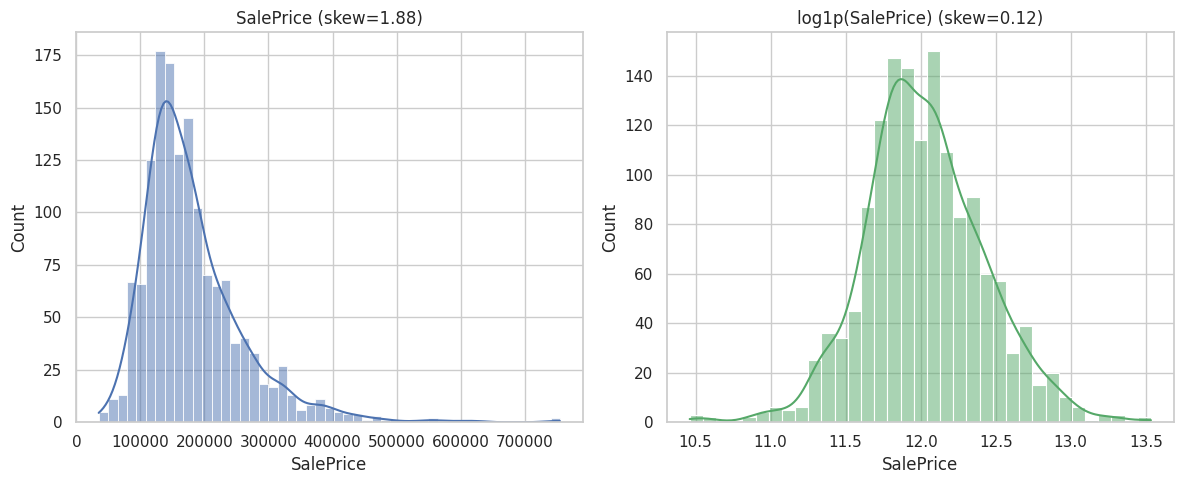

In [ ]:
raw_saleprice = train["SalePrice"].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(raw_saleprice, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title(f"SalePrice (skew={skew(raw_saleprice):.2f})")
sns.histplot(np.log1p(raw_saleprice), kde=True, ax=axes[1], color="#55A868")
axes[1].set_title(f"log1p(SalePrice) (skew={skew(np.log1p(raw_saleprice)):.2f})")
plt.tight_layout()
plt.show()

## 4. EDA корреляций: какие числовые признаки сильнее всего связаны с ценой

Считаю корреляцию Пирсона каждого числового признака с `SalePrice`, вывожу топ-15 и строю heatmap, чтобы заметить сильно коррелирующие между собой признаки и понять, какие признаки несут сигнал.



Топ-15 признаков, коррелирующих с SalePrice:
OverallQual     0.795774
GrLivArea       0.734968
TotalBsmtSF     0.651153
GarageCars      0.641047
1stFlrSF        0.631530
GarageArea      0.629217
FullBath        0.562165
TotRmsAbvGrd    0.537769
YearBuilt       0.523608
YearRemodAdd    0.507717
GarageYrBlt     0.487156
MasVnrArea      0.482719
Fireplaces      0.469862
BsmtFinSF1      0.409384
LotFrontage     0.370584
Name: SalePrice, dtype: float64


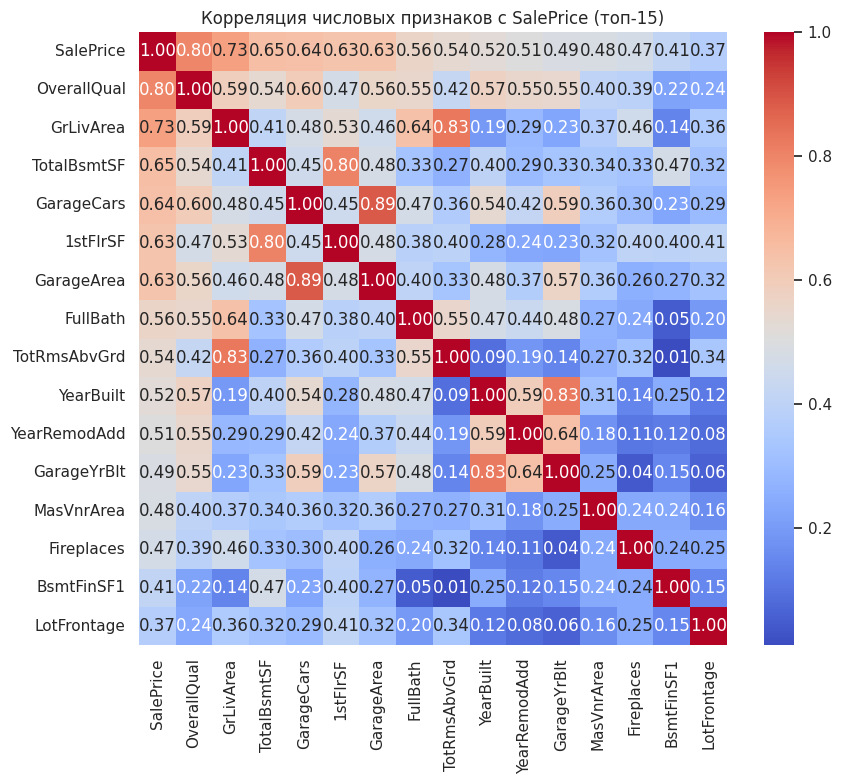

In [ ]:
numeric_train = train.select_dtypes(include=[np.number]).copy()
corr_with_target = numeric_train.corr()["SalePrice"].sort_values(ascending=False)
print("Топ-15 признаков, коррелирующих с SalePrice:")
print(corr_with_target.head(16).drop("SalePrice"))

top_corr_cols = corr_with_target.head(16).index
plt.figure(figsize=(9, 8))
sns.heatmap(numeric_train[top_corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляция числовых признаков с SalePrice (топ-15)")
plt.tight_layout()
plt.show()

## 5. Объединяю train и test: обрабатываю признаки одинаково, метки теста не трогаю
Отделяю `Id` и `SalePrice`, беру `y = log1p(SalePrice)` как целевую переменную, склеиваю train и test в одну таблицу `all_data`. Запоминаю `ntrain` — число обучающих строк, чтобы потом разрезать таблицу обратно.

Пропуски, кодирование категорий и новые признаки должны выполняться одинаково для train и test. Если кодировать их отдельно, наборы one-hot колонок могут не совпасть, и модель не сможет применить обучение к тесту.



In [ ]:
train_ID = train["Id"].copy()
test_ID = test["Id"].copy()
y = np.log1p(train["SalePrice"])  # метрика соревнования - RMSLE => работаем в логарифме

train = train.drop(["Id", "SalePrice"], axis=1)
test = test.drop(["Id"], axis=1)

ntrain = train.shape[0]
all_data = pd.concat([train, test], axis=0, ignore_index=True)
print(f"all_data: {all_data.shape}, ntrain={ntrain}")

all_data: (2917, 79), ntrain=1458


## 6. EDA пропусков

Считаю количество и долю пропусков в каждой колонке и строю график топ-25.

Пропуски бывают двух типов, и для них нужны разные стратегии:
- «признака нет» (нет бассейна: `PoolQC = NA`): правильно заполнить отдельной категорией или нулём;
- «значение потеряно» (единичная пропущенная площадь): правильно заполнить медианой или модой.

Если смешать эти типы, модель получит ложный сигнал. Например, «NA» и «медиана» для бассейна означали бы, что бассейн есть, но его площадь неизвестна.



Признаков с пропусками: 34


,missing,pct_%
PoolQC,2908,99.69
MiscFeature,2812,96.40
Alley,2719,93.21
Fence,2346,80.43
MasVnrType,1766,60.54
FireplaceQu,1420,48.68
LotFrontage,486,16.66
GarageQual,159,5.45
GarageYrBlt,159,5.45
GarageCond,159,5.45


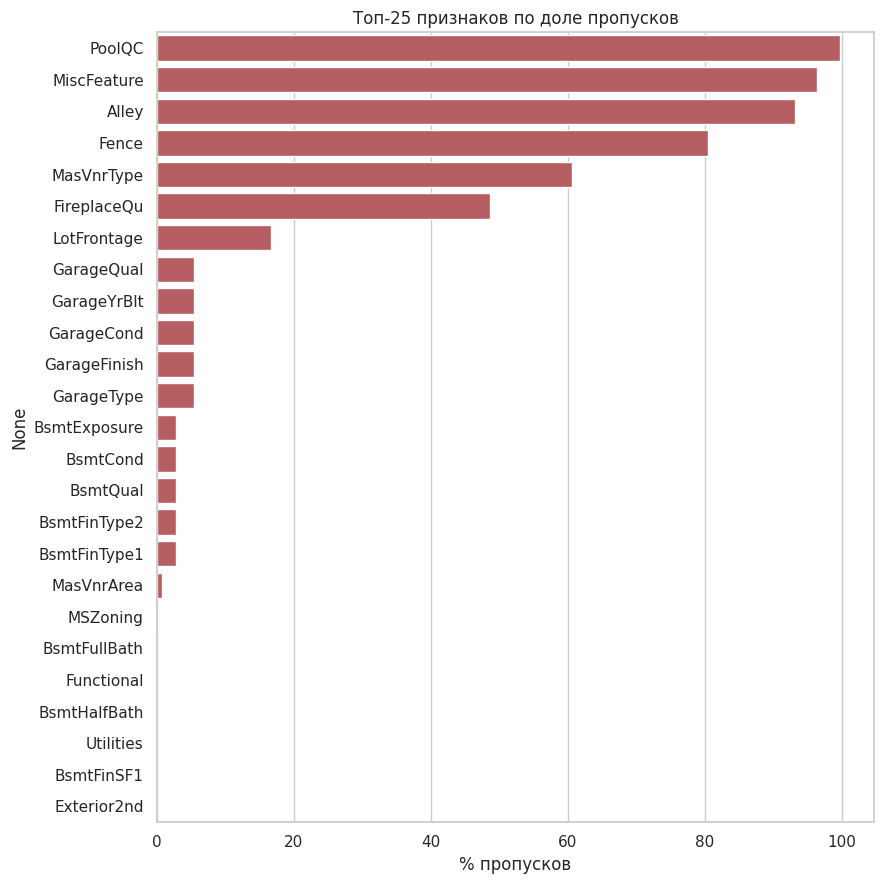

In [ ]:
missing = all_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(all_data) * 100).round(2)
print(f"Признаков с пропусками: {len(missing)}")
display(pd.DataFrame({"missing": missing, "pct_%": missing_pct}).head(20))

plt.figure(figsize=(9, 9))
sns.barplot(x=missing_pct.values[:25], y=missing_pct.index[:25], color="#C44E52")
plt.xlabel("% пропусков")
plt.title("Топ-25 признаков по доле пропусков")
plt.tight_layout()
plt.show()

## 7. Обработка пропусков

Заполняю пропуски разными способами в зависимости от смысла признака.



Utilities: почти все значения одинаковы (AllPub), признак не несёт информации.

In [ ]:
all_data = all_data.drop(["Utilities"], axis=1)

Явная опечатка в данных: GarageYrBlt=2207 (дом не мог быть продан до постройки гаража).

In [ ]:
all_data.loc[all_data["GarageYrBlt"] > 2010, "GarageYrBlt"] = all_data["YearBuilt"]

Отдельная категория колонок с "None".

In [ ]:
none_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType",
]
for col in none_cols:
    all_data[col] = all_data[col].fillna("None")

Отдельная категория, где NA это численно 0.

In [ ]:
zero_cols = [
    "GarageYrBlt", "GarageArea", "GarageCars",
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath", "MasVnrArea",
]
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

Дома в одном районе обычно похожи по ширине фасада поэтому берем медиану по Neighborhood.

In [ ]:
all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"].transform(
    lambda s: s.fillna(s.median())
)
all_data["LotFrontage"] = all_data["LotFrontage"].fillna(all_data["LotFrontage"].median())

Единичные пропуски в категориальных признаках заполняем модой.

In [ ]:
mode_cols = ["MSZoning", "Electrical", "KitchenQual", "Exterior1st", "Exterior2nd", "SaleType"]
for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

all_data["Functional"] = all_data["Functional"].fillna("Typ")

In [ ]:
assert all_data.isnull().sum().sum() == 0, "Остались необработанные пропуски!"
print("Все пропуски обработаны.")

Все пропуски обработаны.


## 8. Типизация и ordinal-кодирование порядковых шкал

`MSSubClass` — числовой код типа дома, а не величина, поэтому переводим в строку. Шкалы качества (`Po, Fa, TA, Gd, Ex` и аналогичные) кодируем числами с сохранением порядка, чтобы модель видела заложенную упорядоченность.

In [ ]:
all_data["MSSubClass"] = all_data["MSSubClass"].astype(str)

qual_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
for col in ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
            "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]:
    all_data[col] = all_data[col].map(qual_map)

all_data["BsmtExposure"] = all_data["BsmtExposure"].map({"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4})
bsmt_fin_map = {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
all_data["BsmtFinType1"] = all_data["BsmtFinType1"].map(bsmt_fin_map)
all_data["BsmtFinType2"] = all_data["BsmtFinType2"].map(bsmt_fin_map)
all_data["GarageFinish"] = all_data["GarageFinish"].map({"None": 0, "Unf": 1, "RFn": 2, "Fin": 3})
all_data["Fence"] = all_data["Fence"].map({"None": 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4})
all_data["LotShape"] = all_data["LotShape"].map({"IR3": 0, "IR2": 1, "IR1": 2, "Reg": 3})
all_data["LandSlope"] = all_data["LandSlope"].map({"Sev": 0, "Mod": 1, "Gtl": 2})
all_data["PavedDrive"] = all_data["PavedDrive"].map({"N": 0, "P": 1, "Y": 2})
all_data["Street"] = all_data["Street"].map({"Grvl": 0, "Pave": 1})
all_data["Alley"] = all_data["Alley"].map({"None": 0, "Grvl": 1, "Pave": 2})
all_data["CentralAir"] = all_data["CentralAir"].map({"N": 0, "Y": 1})
print("Ordinal-кодирование завершено.")

Ordinal-кодирование завершено.


## 9. Добавление признаков

Добавляем агрегированные и производные признаки: суммарную площадь, суммарное число ванных, возраст дома/ремонта/гаража, бинарные флаги наличия удобств, взаимодействия качества и площади.
- `TotalSF` — общая площадь (подвал + оба этажа). Покупатель смотрит на «сколько всего квадратов», а не на каждый этаж отдельно.
- `TotalBath` — число ванных с учётом полуванных (0.5).
- `TotalPorchSF` — суммарная площадь веранд и террас.
- `HouseAge`, `RemodAge`, `GarageAge` — возраст дома, возраст последнего ремонта, возраст гаража. Возраст лучше отражает износ, чем год постройки, потому что модель учится на величине, а не на номере года.
- `Has*`-флаги — есть ли бассейн, второй этаж, гараж, подвал, камин; и был ли дом перестроен.
- `Qual_x_SF`, `Qual_x_GrLivArea` — произведения качества на площадь: хороший дом большой площади стоит дороже, чем сумма вкладов по отдельности.
- `MoSold`, `YrSold` → категории: сезон и год продажи влияют на цену нелинейно (например, весной продают активнее).

In [ ]:
all_data["TotalSF"] = all_data["TotalBsmtSF"] + all_data["1stFlrSF"] + all_data["2ndFlrSF"]
all_data["TotalBath"] = (
    all_data["FullBath"] + 0.5 * all_data["HalfBath"]
    + all_data["BsmtFullBath"] + 0.5 * all_data["BsmtHalfBath"]
)
all_data["TotalPorchSF"] = (
    all_data["OpenPorchSF"] + all_data["EnclosedPorch"]
    + all_data["3SsnPorch"] + all_data["ScreenPorch"] + all_data["WoodDeckSF"]
)
all_data["HouseAge"] = (all_data["YrSold"] - all_data["YearBuilt"]).clip(lower=0)
all_data["RemodAge"] = (all_data["YrSold"] - all_data["YearRemodAdd"]).clip(lower=0)
all_data["GarageAge"] = np.where(
    all_data["GarageYrBlt"] == 0, 0, (all_data["YrSold"] - all_data["GarageYrBlt"]).clip(lower=0)
)

all_data["HasPool"] = (all_data["PoolArea"] > 0).astype(int)
all_data["Has2ndFloor"] = (all_data["2ndFlrSF"] > 0).astype(int)
all_data["HasGarage"] = (all_data["GarageArea"] > 0).astype(int)
all_data["HasBsmt"] = (all_data["TotalBsmtSF"] > 0).astype(int)
all_data["HasFireplace"] = (all_data["Fireplaces"] > 0).astype(int)
all_data["IsRemodeled"] = (all_data["YearBuilt"] != all_data["YearRemodAdd"]).astype(int)

all_data["Qual_x_SF"] = all_data["OverallQual"] * all_data["TotalSF"]
all_data["Qual_x_GrLivArea"] = all_data["OverallQual"] * all_data["GrLivArea"]

all_data["MoSold"] = all_data["MoSold"].astype(str)
all_data["YrSold"] = all_data["YrSold"].astype(str)
print(f"all_data после feature engineering: {all_data.shape}")

all_data после feature engineering: (2917, 92)


## 10. Снижение скошенности числовых признаков (Box-Cox)

Для числовых признаков с асимметрией > 0.75 применяем Box-Cox через `boxcox1p` с параметром $\lambda = 0.15$. Бинарные признаки (0/1) пропускаем.



In [ ]:
numeric_feats = all_data.dtypes[all_data.dtypes != "object"].index
binary_like = [c for c in numeric_feats if all_data[c].nunique() <= 2]
skew_candidates = [c for c in numeric_feats if c not in binary_like]

skewed_feats = all_data[skew_candidates].apply(lambda x: skew(x)).sort_values(ascending=False)
skewed_feats = skewed_feats[abs(skewed_feats) > 0.75]
print(f"Сильно скошенных числовых признаков (|skew|>0.75): {len(skewed_feats)}")

for feat in skewed_feats.index:
    all_data[feat] = boxcox1p(all_data[feat], 0.15)

Сильно скошенных числовых признаков (|skew|>0.75): 38


## 11. One-hot кодирование

`pd.get_dummies` превращает оставшиеся строковые колонки в бинарные: например, `Neighborhood` с 25 районами станет 24 колонками вида `Neighborhood_NoRidge` (0 или 1).



In [ ]:
all_data = pd.get_dummies(all_data, drop_first=True)
print(f"Размер данных после one-hot кодирования: {all_data.shape}")

Размер данных после one-hot кодирования: (2917, 245)


## 12. Разделение обратно на train/test
Разрезаю `all_data` по `ntrain`: первые строки — `X` (обучающая выборка), остальные — `X_test` (тест). Вектор `y` уже готов.


In [ ]:
X = all_data.iloc[:ntrain, :].reset_index(drop=True)
X_test = all_data.iloc[ntrain:, :].reset_index(drop=True)
print(f"X: {X.shape}, X_test: {X_test.shape}, y: {y.shape}")

X: (1458, 245), X_test: (1459, 245), y: (1458,)


## 13. Масштабирование признаков (RobustScaler)
После логарифмов и Box-Cox признаки всё ещё имеют разный масштаб: площадь измеряется тысячами, а флаги — нулями и единицами. Для Ridge, Lasso и ElasticNet это критично: штраф одинаково давит на все коэффициенты, поэтому признаки с маленькими числами будут подавлены несправедливо. Деревья от масштаба не зависят, но и не страдают от него.

`RobustScaler` вычитает медиану и делит на межквартильный размах (IQR) каждого признака. Обучаем его только на train, чтобы не было утечки информации из test.


In [ ]:
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
X_scaled.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
LotFrontage,1458.0,-0.141440,1.102756,-3.794380,-0.530036,0.000000e+00,0.469964,5.881710
LotArea,1458.0,-0.065483,1.195442,-3.999177,-0.521580,1.047556e-15,0.478420,9.276971
Street,1458.0,-0.004115,0.064040,-1.000000,0.000000,0.000000e+00,0.000000,0.000000
Alley,1458.0,0.058635,0.234540,0.000000,0.000000,0.000000e+00,0.000000,1.194318
LotShape,1458.0,-0.424466,0.653538,-4.445361,-1.000000,0.000000e+00,0.000000,0.000000


## 14. Кросс-валидация: настройка
Создаю `KFold` на 5 фолдов с перемешиванием и фиксированным `random_state`.
Все модели сравниваю на одинаковых фолдах по метрике RMSE на `log(SalePrice)` — это эквивалентно RMSLE.

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = "neg_root_mean_squared_error"
searches = {}

## 15. Ridge: базовая линейная модель, подбираю силу $L2$-штрафа $\alpha$ по сетке

In [ ]:
ridge_grid = {"alpha": [0.1, 0.3, 1, 3, 5, 8, 10, 15, 20, 30, 50]}
searches["Ridge"] = GridSearchCV(Ridge(random_state=RANDOM_STATE), ridge_grid,
                                  scoring=SCORING, cv=kf, n_jobs=-1)
searches["Ridge"].fit(X_scaled, y)
print(f"Ridge best RMSE={-searches['Ridge'].best_score_:.5f}, params={searches['Ridge'].best_params_}")

Ridge best RMSE=0.11425, params={'alpha': 15}


## 16. Lasso: $L1$-штраф может обнулять слабые признаки, подбираю $\alpha$ по сетке

In [ ]:
lasso_grid = {"alpha": [0.0001, 0.0003, 0.0005, 0.0007, 0.001, 0.003, 0.005, 0.01]}
searches["Lasso"] = GridSearchCV(Lasso(random_state=RANDOM_STATE, max_iter=50000), lasso_grid,
                                  scoring=SCORING, cv=kf, n_jobs=-1)
searches["Lasso"].fit(X_scaled, y)
print(f"Lasso best RMSE={-searches['Lasso'].best_score_:.5f}, params={searches['Lasso'].best_params_}")

Lasso best RMSE=0.11407, params={'alpha': 0.0007}


## 17. ElasticNet: компромисс между Ridge и Lasso, подбираем $\alpha$ и долю $L1$ ($l1_{ratio}$)

In [ ]:
enet_grid = {"alpha": [0.0003, 0.0005, 0.001, 0.003, 0.005], "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]}
searches["ElasticNet"] = GridSearchCV(ElasticNet(random_state=RANDOM_STATE, max_iter=50000), enet_grid,
                                       scoring=SCORING, cv=kf, n_jobs=-1)
searches["ElasticNet"].fit(X_scaled, y)
print(f"ElasticNet best RMSE={-searches['ElasticNet'].best_score_:.5f}, params={searches['ElasticNet'].best_params_}")

ElasticNet best RMSE=0.11406, params={'alpha': 0.005, 'l1_ratio': 0.1}


## 18. Random Forest: нелинейная модель c большим пространством параметров. Поэтому использую `RandomizedSearchCV` вместо полного перебора

In [ ]:
rf_grid = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [None, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5, 0.7],
}
searches["RandomForest"] = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1), rf_grid,
    n_iter=25, scoring=SCORING, cv=kf, random_state=RANDOM_STATE, n_jobs=-1,
)
searches["RandomForest"].fit(X_scaled, y)
print(f"RandomForest best RMSE={-searches['RandomForest'].best_score_:.5f}, params={searches['RandomForest'].best_params_}")

RandomForest best RMSE=0.13069, params={'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}


## 19. Gradient Boosting: деревья исправляют ошибки друг друга, баланс темпа обучения и глубины

In [ ]:
gbr_grid = {
    "n_estimators": [300, 500, 800, 1200],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.6, 0.8, 1.0],
    "min_samples_leaf": [1, 3, 5],
}
searches["GradientBoosting"] = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE), gbr_grid,
    n_iter=25, scoring=SCORING, cv=kf, random_state=RANDOM_STATE, n_jobs=-1,
)
searches["GradientBoosting"].fit(X_scaled, y)
print(f"GradientBoosting best RMSE={-searches['GradientBoosting'].best_score_:.5f}, params={searches['GradientBoosting'].best_params_}")

GradientBoosting best RMSE=0.11681, params={'subsample': 0.6, 'n_estimators': 1200, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.03}


## 20. XGBoost: бустинг с $L1$/$L2$-регуляризацией и подвыборкой признаков



In [ ]:
if HAS_XGB:
    xgb_grid = {
        "n_estimators": [500, 800, 1200, 1500],
        "learning_rate": [0.01, 0.03, 0.05],
        "max_depth": [2, 3, 4, 5],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.5, 0.7, 0.9],
        "reg_alpha": [0, 0.001, 0.01],
        "reg_lambda": [0.5, 1, 2],
    }
    searches["XGBoost"] = RandomizedSearchCV(
        XGBRegressor(random_state=RANDOM_STATE, n_jobs=1, objective="reg:squarederror"),
        xgb_grid, n_iter=30, scoring=SCORING, cv=kf, random_state=RANDOM_STATE, n_jobs=-1,
    )
    searches["XGBoost"].fit(X_scaled, y)
    print(f"XGBoost best RMSE={-searches['XGBoost'].best_score_:.5f}, params={searches['XGBoost'].best_params_}")
else:
    print("xgboost не установлен (pip install xgboost) - пропускаю модель.")

XGBoost best RMSE=0.11559, params={'subsample': 0.6, 'reg_lambda': 2, 'reg_alpha': 0.001, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.5}


## 21. LightGBM: быстрый бустинг с ростом деревьев по листьям, подбираем сложность



In [ ]:
if HAS_LGBM:
    lgbm_grid = {
        "n_estimators": [500, 800, 1200, 1500],
        "learning_rate": [0.01, 0.03, 0.05],
        "num_leaves": [15, 31, 63],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.5, 0.7, 0.9],
        "reg_alpha": [0, 0.001, 0.01],
        "reg_lambda": [0.5, 1, 2],
    }
    searches["LightGBM"] = RandomizedSearchCV(
        LGBMRegressor(random_state=RANDOM_STATE, n_jobs=1, verbose=-1),
        lgbm_grid, n_iter=30, scoring=SCORING, cv=kf, random_state=RANDOM_STATE, n_jobs=-1,
    )
    searches["LightGBM"].fit(X_scaled, y)
    print(f"LightGBM best RMSE={-searches['LightGBM'].best_score_:.5f}, params={searches['LightGBM'].best_params_}")
else:
    print("lightgbm не установлен (pip install lightgbm) - пропускаю модель.")

LightGBM best RMSE=0.11853, params={'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.001, 'num_leaves': 15, 'n_estimators': 1500, 'learning_rate': 0.01, 'colsample_bytree': 0.5}


## 22. Сравнение модели по одной метрике на одних фолдах и выбор лучшей

In [ ]:
print("================= Результаты (RMSE на log(SalePrice), 5-fold CV) =================")
results = {}
for name, search in searches.items():
    rmse = -search.best_score_
    results[name] = rmse
    print(f"{name:>17}: RMSE={rmse:.5f}  | best_params={search.best_params_}")

best_name = min(results, key=results.get)
best_model = searches[best_name].best_estimator_
print(f"\nЛучшая одиночная модель: {best_name} (RMSE={results[best_name]:.5f})")

================= Результаты (RMSE на log(SalePrice), 5-fold CV) =================
            Ridge: RMSE=0.11425  | best_params={'alpha': 15}
            Lasso: RMSE=0.11407  | best_params={'alpha': 0.0007}
       ElasticNet: RMSE=0.11406  | best_params={'alpha': 0.005, 'l1_ratio': 0.1}
     RandomForest: RMSE=0.13069  | best_params={'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}
 GradientBoosting: RMSE=0.11681  | best_params={'subsample': 0.6, 'n_estimators': 1200, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.03}
          XGBoost: RMSE=0.11559  | best_params={'subsample': 0.6, 'reg_lambda': 2, 'reg_alpha': 0.001, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.5}
         LightGBM: RMSE=0.11853  | best_params={'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.001, 'num_leaves': 15, 'n_estimators': 1500, 'learning_rate': 0.01, 'colsample_bytree': 0.5}

Лучшая одиночная модель:

## 23. Диагностика лучшей модели: где она ошибается и нет ли систематического смещения

Строю out-of-fold предсказания: каждый дом предсказан моделью, которая его не видела при обучении. По ним строю график «факт vs прогноз» и гистограмму остатков.

OOF RMSE (в долларах): 21,952, R2: 0.9237


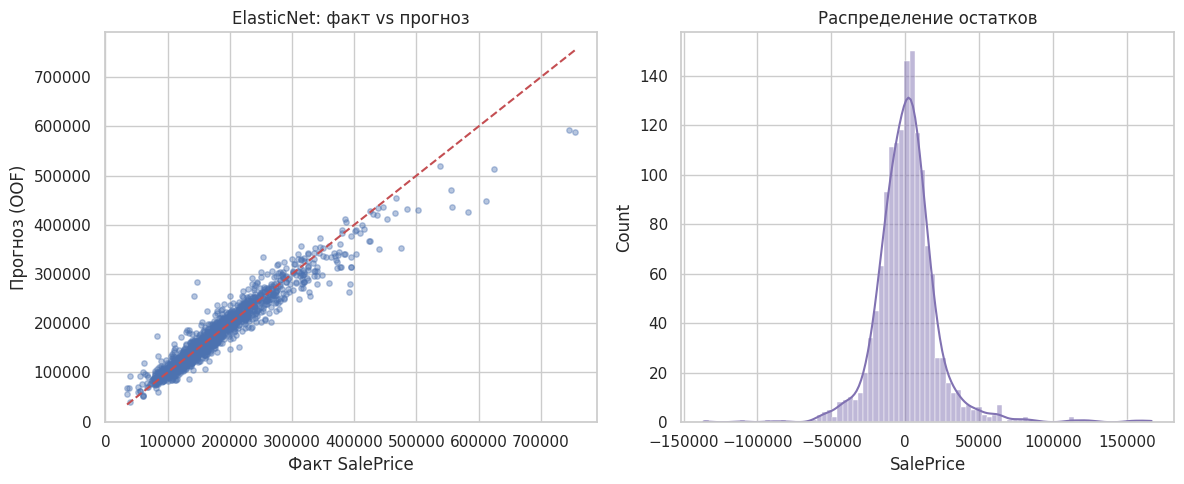

In [ ]:
oof_pred_log = cross_val_predict(best_model, X_scaled, y, cv=kf, n_jobs=-1)
oof_pred = np.expm1(oof_pred_log)
y_true = np.expm1(y)

rmse_dollars = np.sqrt(mean_squared_error(y_true, oof_pred))
r2 = r2_score(y_true, oof_pred)
print(f"OOF RMSE (в долларах): {rmse_dollars:,.0f}, R2: {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_true, oof_pred, alpha=0.4, s=15)
lims = [y_true.min(), y_true.max()]
axes[0].plot(lims, lims, "r--")
axes[0].set_xlabel("Факт SalePrice")
axes[0].set_ylabel("Прогноз (OOF)")
axes[0].set_title(f"{best_name}: факт vs прогноз")

residuals = y_true - oof_pred
sns.histplot(residuals, kde=True, ax=axes[1], color="#8172B2")
axes[1].set_title("Распределение остатков")
plt.tight_layout()
plt.show()

## 24. Важность признаков

Проверяю, что модель опирается на осмысленные признаки (качество, площадь, возраст), а не на случайный шум. Если неожиданный признак оказался в топе, это повод проверить данные.

Для деревьев беру `feature_importances_`, для линейных моделей - модуль коэффициентов. Благодаря масштабированию коэффициенты сравнимы между собой.


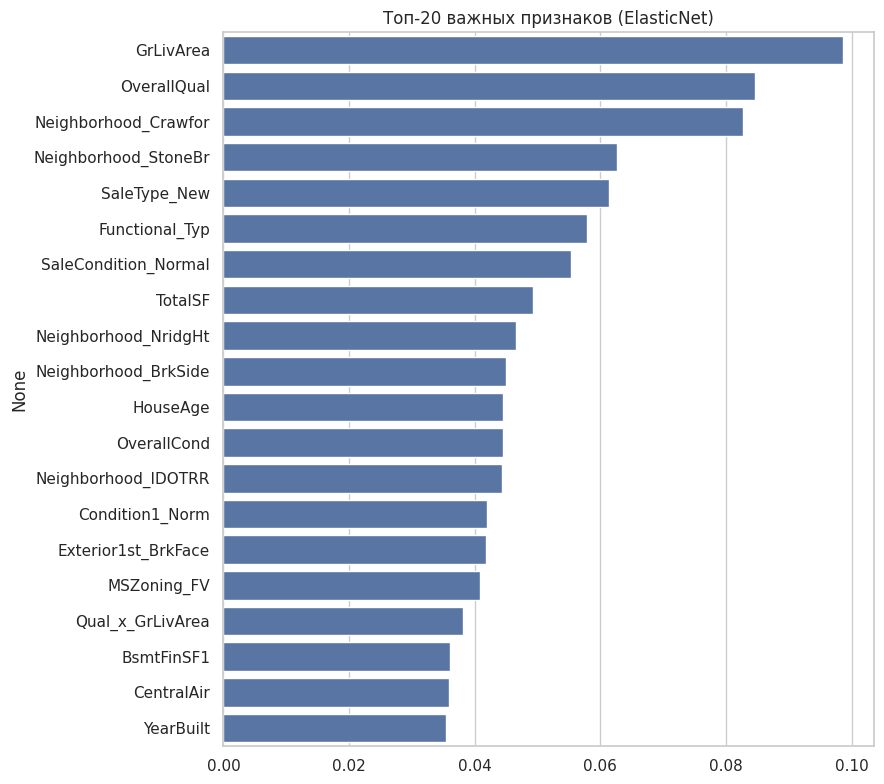

In [ ]:
if hasattr(best_model, "feature_importances_"):
    importance = pd.Series(best_model.feature_importances_, index=X.columns)
elif hasattr(best_model, "coef_"):
    importance = pd.Series(np.abs(best_model.coef_), index=X.columns)
else:
    importance = None

if importance is not None:
    top20 = importance.sort_values(ascending=False).head(20)
    plt.figure(figsize=(9, 8))
    sns.barplot(x=top20.values, y=top20.index, color="#4C72B0")
    plt.title(f"Топ-20 важных признаков ({best_name})")
    plt.tight_layout()
    plt.show()

## 25. Ансамбль топ-3 моделей и итоговый submission.csv

Разные модели ошибаются по-разному. Усреднение уменьшает дисперсию ошибки и обычно даёт результат лучше, чем любая модель в отдельности. Усреднять удобнее в логарифмах, потому что обучение и метрика тоже в логарифмах.

Беру три лучшие модели по CV, усредняю их предсказания в логарифмической шкале и возвращаю в доллары через `expm1`. Результат сохраняю в `submission.csv`.



In [ ]:
top3_names = sorted(results, key=results.get)[:3]
print(f"Ансамбль (простое усреднение) из топ-3 моделей: {top3_names}")

test_preds_log = np.mean(
    [searches[name].best_estimator_.predict(X_test_scaled) for name in top3_names], axis=0
)
test_preds = np.expm1(test_preds_log)

submission = pd.DataFrame({"Id": test_ID, "SalePrice": test_preds})
submission.to_csv("submission.csv", index=False)
print(f"Готово. Submission сохранён: {"submission.csv"}")
submission.head()

Ансамбль (простое усреднение) из топ-3 моделей: ['ElasticNet', 'Lasso', 'Ridge']
Готово. Submission сохранён: submission.csv


,Id,SalePrice
0,1461,115535.346406
1,1462,156670.629772
2,1463,180943.832938
3,1464,201782.011587
4,1465,197353.334165
